# Encoder

In [79]:
%run helperFunctions.ipynb

read: ./data/faulty\Circuit_Scenario1_batery_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario1_switch1_broken_res.csv
read: ./data/faulty\Circuit_Scenario2_battery2_broken_res.csv
read: ./data/faulty\Circuit_Scenario2_battery2_empty_res.csv
read: ./data/faulty\Circuit_Scenario2_switch_2_broken_res.csv
read: ./data/faulty\Circuit_Scenario3_battery_1_empty_res.csv
read: ./data/faulty\Circuit_Scenario3_switch_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario4_battery_1_broken_res.csv
read: ./data/faulty\Circuit_Scenario4_battery_1_empty_res.csv
read: ./data/faulty\Circuit_Scenario4_switch_1_broken_res.csv
read: ./data/faultless\Circuit_Scenario1_res.csv
read: ./data/faultless\Circuit_Scenario2_res.csv
read: ./data/faultless\Circuit_Scenario3_res.csv
read: ./data/faultless\Circuit_Scenario4_res.csv


In [80]:
def build_float_to_boolean_encoder():
    # 1) Input layer for two float inputs
    input_layer = tf.keras.Input(shape=(2,), name="float_input")  # Shape (batch_size, 2)

    # Create a normalization layer
    norm = layers.Normalization(axis=-1)
   
    x = norm(input_layer)

    #x = layers.Dense(64, activation='relu')(x)
    #x = layers.Dropout(0.1)(x) 
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.1)(x)  # 20% dropout for regularization
    x = layers.Dense(16, activation='relu')(x)
    x = layers.Dropout(0.1)(x)  # another dropout
    x = layers.Dense(8, activation='relu')(x)
    x = layers.Dropout(0.1)(x) 

    outputs = layers.Dense(3, activation='sigmoid')(x)

    model = Model(inputs=input_layer, outputs=outputs)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        #metrics=['accuracy']  
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='binary_accuracy'),
            tf.keras.metrics.AUC(name='auc')
        ]
        # Tracks the accuracy of individual bits (0/1)
    )

    # Return both the model and the normalization layer (we'll adapt it later)
    return model, norm



In [81]:
def train(with_validation = False): 
    model, norm_layer = build_float_to_boolean_encoder()
    df = getTrainingDataResistance()
    y = df[["circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"]].astype(float).values
    # Convert output column to float as well:
    X = df[["circ1.r_load.v", "circ1.r_load.r_int"]].astype(float).values
    Y_binary = y - 1.0

 
    model.summary()
    
     
    history = model.fit(
        X, 
        Y_binary, 
        epochs=20,       
        batch_size=4,
        verbose=1
    )

    
    
    plt.plot(history.history['loss'], label='Training Loss')
    if with_validation:
        plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.legend()
    plt.show()
    return model, norm_layer
   

read: ./data/training/Circuit_ScenarioDataGeneration_Volatage_Restistance_res.csv
Model: "model_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 float_input (InputLayer)    [(None, 2)]               0         
                                                                 
 normalization_5 (Normalizat  (None, 2)                5         
 ion)                                                            
                                                                 
 dense_52 (Dense)            (None, 32)                96        
                                                                 
 dropout_39 (Dropout)        (None, 32)                0         
                                                                 
 dense_53 (Dense)            (None, 16)                528       
                                                                 
 dropout_40 (Dropout)        (None, 16)   

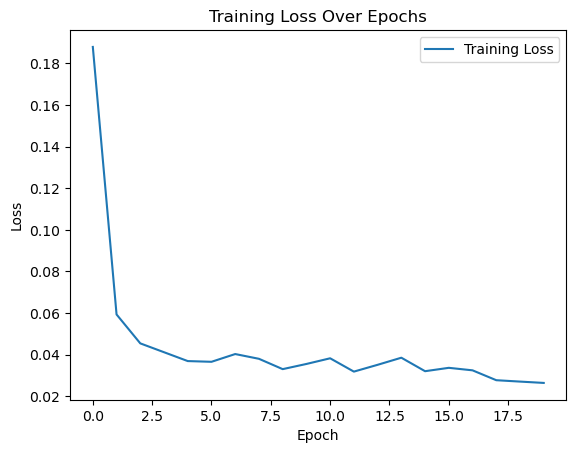

In [82]:
model, norm_layer = train()

In [83]:
def test(model, norm_layer): 
    #wtf why does mixed data behave differently 
    #sdf = getFaultyData()
    df = getFaultlessData()
   # df = df_f.append(df_l)
    #df = getMixedData()
   # print(f"X shape: {df_f.shape}, y shape: {df_l.shape}, y shape: {df.shape}")
    #df = df_old.drop_duplicates(subset=["circ1.r_load.v", "circ1.r_load.r_int", 
         #                        "circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"])
    y = df[["circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"]].astype(float).values
    # Convert output column to float as well:
    X = df[["circ1.r_load.v", "circ1.r_load.r_int"]].astype(float).values
    Y_binary = y - 1.0
    
    
    norm_layer.adapt(X)
    preds_raw = model.predict(X)
    preds_binary = (preds_raw > 0.5).astype(int)
    #for real, preds in zip(Y_binary, preds_binary):
        #print(f"Real: {real} | Predictions: {preds}")

    anomaly_mask = getAnomalyMask(df)
    print(f"X shape: {X.shape}, y shape: {y.shape}, anomaly_mask length: {len(anomaly_mask)}")
#print(anomolous)
#Y_binary_d
    falseNegative = 0
    falsePositive = 0
    truePositive = 0
    trueNegative = 0 
    
    for real, preds, anom in zip(Y_binary, preds_binary, anomaly_mask):
        mismatch = (
            int(real[0]) != int(preds[0]) or
            int(real[1]) != int(preds[1]) or
            int(real[2]) != int(preds[2])
        )
   
        if mismatch:
        #
            if anom == False:
                #print(mismatch)
                #print("Error False")
                print(f"Real: {real} | Predictions: {preds} | anom: {anom}")
                falsePositive += 1
            else: 
                truePositive += 1
        else: 
            if anom == True:
                #print(mismatch)
                #print("Error True")
                #print(f"Real: {real} | Predictions: {preds} | anom: {anom}")
                falseNegative += 1
            else: 
                trueNegative += 1
        

    print(f"falseNegative: {falseNegative} | falsePositive: {falsePositive} | truePositive: {truePositive} | trueNegative: {trueNegative}")

    

In [84]:
test(model, norm_layer)

read: ./data/faultless\Circuit_Scenario1_res.csv
read: ./data/faultless\Circuit_Scenario2_res.csv
read: ./data/faultless\Circuit_Scenario3_res.csv
read: ./data/faultless\Circuit_Scenario4_res.csv
18/18 [==============================] - 0s 941us/step
X shape: (576, 2), y shape: (576, 3), anomaly_mask length: 576
Real: [1. 1. 1.] | Predictions: [1 0 0] | anom: False
Real: [1. 1. 1.] | Predictions: [1 0 0] | anom: False
Real: [1. 1. 1.] | Predictions: [1 0 0] | anom: False
Real: [1. 1. 1.] | Predictions: [1 0 0] | anom: False
Real: [1. 1. 1.] | Predictions: [1 0 0] | anom: False
Real: [1. 1. 1.] | Predictions: [1 0 0] | anom: False
Real: [1. 1. 1.] | Predictions: [1 0 0] | anom: False
Real: [1. 1. 1.] | Predictions: [1 0 0] | anom: False
Real: [1. 1. 1.] | Predictions: [1 0 0] | anom: False
Real: [1. 1. 1.] | Predictions: [1 0 0] | anom: False
Real: [1. 1. 1.] | Predictions: [1 0 0] | anom: False
Real: [1. 1. 1.] | Predictions: [1 0 0] | anom: False
Real: [1. 1. 1.] | Predictions: [1 0 0

In [63]:
def build_float_to_boolean_encoder_with_scaler():
    # 1) Input layer for two float inputs
    input_layer = tf.keras.Input(shape=(2,), name="float_input")  # Shape (batch_size, 2)

    # Placeholder for scaled input (data preprocessing happens outside the model)
    x = input_layer

    # Define the layers of the model
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.1)(x)  # 10% dropout for regularization
    x = layers.Dense(16, activation='relu')(x)
    x = layers.Dropout(0.1)(x)  # another dropout
    x = layers.Dense(8, activation='relu')(x)
    x = layers.Dropout(0.1)(x) 

    # Output layer with 3 boolean outputs
    outputs = layers.Dense(3, activation='sigmoid')(x)

    # Create the model
    model = Model(inputs=input_layer, outputs=outputs)

    # Compile the model
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='binary_accuracy'),
            tf.keras.metrics.AUC(name='auc'),
        ]
    )

    # Initialize a scaler to preprocess the data outside the model
    #scaler = MinMaxScaler()

    return model#, scaler

In [70]:
def trainWithScaler():
    # Build the model without using the normalization layer
    model = build_float_to_boolean_encoder_with_scaler()  # Ignore the normalization layer
    
    # Load the training data
    df = getTrainingDataResistance()
    y = df[["circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"]].astype(float).values
    X = df[["circ1.r_load.v", "circ1.r_load.r_int"]].astype(float).values
    Y_binary = y - 1.0  # Adjust labels to binary format

    # Use a scaler to preprocess the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Print model summary
    model.summary()

    # Train the model with scaled data
    history = model.fit(
        X_scaled,  # Use the scaled input
        Y_binary,
        epochs=20,
        batch_size=4,
        verbose=1
    )

    # Plot the training loss
    plt.plot(history.history['loss'], label='Training Loss')
    if 'val_loss' in history.history:  # Check if validation loss is present
        plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.legend()
    plt.show()

    return model, scaler

read: ./data/training/Circuit_ScenarioDataGeneration_Restistance_res.csv
Model: "model_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 float_input (InputLayer)    [(None, 2)]               0         
                                                                 
 dense_48 (Dense)            (None, 32)                96        
                                                                 
 dropout_36 (Dropout)        (None, 32)                0         
                                                                 
 dense_49 (Dense)            (None, 16)                528       
                                                                 
 dropout_37 (Dropout)        (None, 16)                0         
                                                                 
 dense_50 (Dense)            (None, 8)                 136       
                                                   

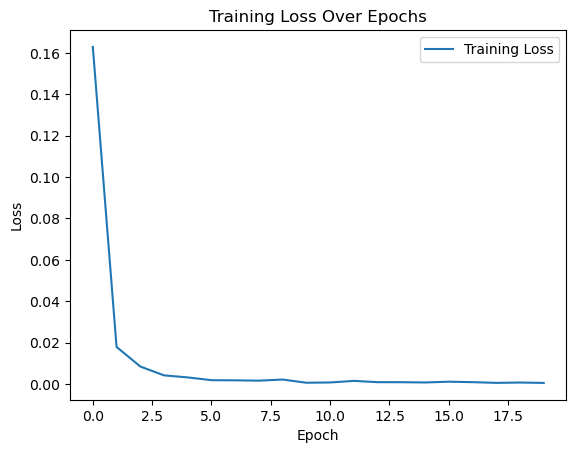

In [71]:
model, scaler = trainWithScaler()

In [73]:
def test(model, scaler):
    # Get the faulty data for testing
    #df = getFaultyData()
    # Uncomment to test with other data:
    df = getFaultlessData()
    #df = getMixedData()

    # Extract target and input features
    y = df[["circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"]].astype(float).values
    X = df[["circ1.r_load.v", "circ1.r_load.r_int"]].astype(float).values
    Y_binary = y - 1.0  # Convert target values to binary format

    # Scale the input data using the provided scaler
    X_scaled = scaler.transform(X)

    # Model prediction
    preds_raw = model.predict(X_scaled)
    preds_binary = (preds_raw > 0.5).astype(int)

    # Get the anomaly mask (assumes this is a boolean array indicating anomalies)
    anomaly_mask = getAnomalyMask(df)
    print(f"X shape: {X.shape}, y shape: {y.shape}, anomaly_mask length: {len(anomaly_mask)}")

    # Initialize counters for confusion matrix components
    falseNegative = 0
    falsePositive = 0
    truePositive = 0
    trueNegative = 0 

    # Compare predictions with ground truth and calculate metrics
    for real, preds, anom in zip(Y_binary, preds_binary, anomaly_mask):
        mismatch = (
            int(real[0]) != int(preds[0]) or
            int(real[1]) != int(preds[1]) or
            int(real[2]) != int(preds[2])
        )

        if mismatch:
            if not anom:
                print(f"Real: {real} | Predictions: {preds} | anom: {anom}")
                falsePositive += 1
            else: 
                truePositive += 1
        else: 
            if anom:
                falseNegative += 1
            else: 
                trueNegative += 1

    # Print confusion matrix results
    print(f"falseNegative: {falseNegative} | falsePositive: {falsePositive} | truePositive: {truePositive} | trueNegative: {trueNegative}")

In [74]:
test(model, scaler)

read: ./data/faultless\Circuit_Scenario1_res.csv
read: ./data/faultless\Circuit_Scenario2_res.csv
read: ./data/faultless\Circuit_Scenario3_res.csv
read: ./data/faultless\Circuit_Scenario4_res.csv
18/18 [==============================] - 0s 882us/step
X shape: (576, 2), y shape: (576, 3), anomaly_mask length: 576
Real: [1. 0. 0.] | Predictions: [1 1 0] | anom: False
Real: [1. 0. 0.] | Predictions: [1 1 0] | anom: False
falseNegative: 0 | falsePositive: 2 | truePositive: 0 | trueNegative: 574


In [ ]:
falseNegative = 1220
truePositive = 366
falsePositive = 2
trueNegative = 574

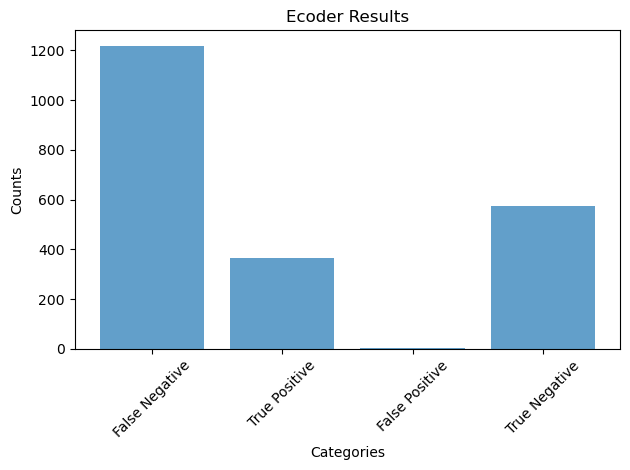

In [77]:
# Data for the histogram
data = {
    "False Negative": 1220,
    "True Positive": 366,
    "False Positive": 2,
    "True Negative": 574
}

# Create the histogram
plt.bar(data.keys(), data.values(), alpha=0.7)

# Add labels and title
plt.xlabel("Categories")
plt.ylabel("Counts")
plt.title("Ecoder Results")
plt.xticks(rotation=45)
plt.savefig('histogram_encoder_results.png', dpi=300, bbox_inches='tight')
# Display the plot
plt.tight_layout()
plt.show()